<a href="https://colab.research.google.com/github/VanThinhVan/DeTaiTTNT/blob/master/RubikCube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kociemba


In [ ]:
import os
import torch
import random
import numpy as np
from google.colab import drive
SEED = 42
def set_seed(seed: int = SEED):
    """Cố định toàn bộ nguồn ngẫu nhiên cho Python, NumPy, PyTorch (CPU + GPU)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"-> [SEED] Đã cố định seed = {seed} cho toàn bộ quá trình huấn luyện.")

set_seed(SEED)

-> [SEED] Đã cố định seed = 42 cho toàn bộ quá trình huấn luyện.


In [ ]:
drive.mount('/content/drive',force_remount=True)
DATA_DIR = "/content/drive/MyDrive/tapdulieu"
os.makedirs(DATA_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n[OK] Hệ thống đã sẵn sàng!")
print(f"-> Thiết bị tăng tốc phần cứng đang dùng: {device}")
print(f"-> Thư mục lưu trữ dữ liệu: {DATA_DIR}")


[OK] Hệ thống đã sẵn sàng!
-> Thiết bị tăng tốc phần cứng đang dùng: cuda
-> Thư mục lưu trữ dữ liệu: /content/drive/MyDrive/tapdulieu


In [ ]:
import os
import torch
import random
import numpy as np
from google.colab import drive
SEED = 42
drive.mount('/content/drive')
DATA_DIR = "/content/drive/MyDrive/tapdulieu"
os.makedirs(DATA_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n[OK] Hệ thống đã sẵn sàng!")
print(f"-> Thiết bị tăng tốc phần cứng đang dùng: {device}")
print(f"-> Thư mục lưu trữ dữ liệu: {DATA_DIR}")

class Cube:
    MOVES = None
    INV_MOVE = {
        "U": "U'", "U'": "U", "R": "R'", "R'": "R",
        "F": "F'", "F'": "F", "D": "D'", "D'": "D",
        "L": "L'", "L'": "L", "B": "B'", "B'": "B"
    }
    ALL_MOVES = ["U", "U'", "R", "R'", "F", "F'", "D", "D'", "L", "L'", "B", "B'"]

    @classmethod
    def _build_moves(cls):
        if cls.MOVES is not None:
            return
        stickers = []
        for r in range(3):
            for c in range(3): stickers.append(((c - 1, 1, r - 1), (0, 1, 0))) # U
        for r in range(3):
            for c in range(3): stickers.append(((1, 1 - r, 1 - c), (1, 0, 0))) # R
        for r in range(3):
            for c in range(3): stickers.append(((c - 1, 1 - r, 1), (0, 0, 1))) # F
        for r in range(3):
            for c in range(3): stickers.append(((c - 1, -1, 1 - r), (0, -1, 0))) # D
        for r in range(3):
            for c in range(3): stickers.append(((-1, 1 - r, c - 1), (-1, 0, 0))) # L
        for r in range(3):
            for c in range(3): stickers.append(((1 - c, 1 - r, -1), (0, 0, -1))) # B

        sticker_map = {(tuple(pos), tuple(normal)): idx for idx, (pos, normal) in enumerate(stickers)}

        RX90 = np.array([[1, 0, 0], [0, 0, -1], [0, 1, 0]], dtype=np.int8)
        RXN90 = np.array([[1, 0, 0], [0, 0, 1], [0, -1, 0]], dtype=np.int8)
        RY90 = np.array([[0, 0, -1], [0, 1, 0], [1, 0, 0]], dtype=np.int8)
        RYN90 = np.array([[0, 0, 1], [0, 1, 0], [-1, 0, 0]], dtype=np.int8)
        RZ90 = np.array([[0, -1, 0], [1, 0, 0], [0, 0, 1]], dtype=np.int8)
        RZN90 = np.array([[0, 1, 0], [-1, 0, 0], [0, 0, 1]], dtype=np.int8)

        move_specs = {
            "U": ("y", 1, RY90), "U'": ("y", 1, RYN90), "D": ("y", -1, RYN90), "D'": ("y", -1, RY90),
            "R": ("x", 1, RXN90), "R'": ("x", 1, RX90), "L": ("x", -1, RX90), "L'": ("x", -1, RXN90),
            "F": ("z", 1, RZN90), "F'": ("z", 1, RZ90), "B": ("z", -1, RZ90), "B'": ("z", -1, RZN90)
        }
        cls.MOVES = {}
        for move, (axis, layer, rot) in move_specs.items():
            perm = np.zeros(54, dtype=np.int32)
            for old_idx, (pos, normal) in enumerate(stickers):
                pos, normal = np.array(pos), np.array(normal)
                rotate = (axis == "x" and pos[0] == layer) or (axis == "y" and pos[1] == layer) or (axis == "z" and pos[2] == layer)
                if rotate:
                    new_pos = tuple((rot @ pos).tolist())
                    new_normal = tuple((rot @ normal).tolist())
                else:
                    new_pos, new_normal = tuple(pos.tolist()), tuple(normal.tolist())
                new_idx = sticker_map[(new_pos, new_normal)]
                perm[new_idx] = old_idx
            cls.MOVES[move] = perm

    def __init__(self, state=None):
        Cube._build_moves()
        if state is None:
            self.state = np.array([0]*9 + [2]*9 + [4]*9 + [1]*9 + [3]*9 + [5]*9, dtype=np.int8)
        else:
            self.state = np.array(state, dtype=np.int8)

    def copy(self):
        obj = Cube.__new__(Cube)
        obj.state = self.state.copy()
        return obj

    def apply_move(self, move):
        self.state = self.state[Cube.MOVES[move]]

    def apply_moves(self, sequence):
        if isinstance(sequence, str): sequence = sequence.split()
        for move in sequence: self.apply_move(move)

    def is_solved(self):
        for face in range(6):
            block = self.state[face * 9 : (face + 1) * 9]
            if np.any(block != block[0]): return False
        return True

    def encode(self):
        out = np.zeros((54, 6), dtype=np.float32)
        out[np.arange(54), self.state] = 1.0
        return out.reshape(-1)

    def to_cubestring(self):
        color_map = {0: "U", 1: "D", 2: "R", 3: "L", 4: "F", 5: "B"}
        return "".join(color_map[c] for c in self.state)

import itertools
def build_cube_symmetries():
    # 1. Tái tạo lại danh sách 54 sticker (vị trí và pháp tuyến)
    stickers = []
    for r in range(3):
        for c in range(3): stickers.append(((c - 1, 1, r - 1), (0, 1, 0)))      # U
    for r in range(3):
        for c in range(3): stickers.append(((1, 1 - r, 1 - c), (1, 0, 0)))      # R
    for r in range(3):
        for c in range(3): stickers.append(((c - 1, 1 - r, 1), (0, 0, 1)))      # F
    for r in range(3):
        for c in range(3): stickers.append(((c - 1, -1, 1 - r), (0, -1, 0)))    # D
    for r in range(3):
        for c in range(3): stickers.append(((-1, 1 - r, c - 1), (-1, 0, 0)))    # L
    for r in range(3):
        for c in range(3): stickers.append(((1 - c, 1 - r, -1), (0, 0, -1)))    # B

    sticker_map = {(tuple(pos), tuple(normal)): idx for idx, (pos, normal) in enumerate(stickers)}

    # 2. Sinh 24 ma trận xoay 3D (định thức = 1)
    rot_mats = []
    for perm in itertools.permutations([0, 1, 2]):
        for signs in itertools.product([-1, 1], repeat=3):
            mat = np.zeros((3, 3), dtype=np.int8)
            mat[0, perm[0]] = signs[0]
            mat[1, perm[1]] = signs[1]
            mat[2, perm[2]] = signs[2]
            if np.linalg.det(mat) == 1:
                rot_mats.append(mat)

    # 3. Tính ma trận hoán vị (permutation) 54 phần tử cho mỗi phép xoay
    sym_perms = []
    for R in rot_mats:
        perm = np.zeros(54, dtype=np.int64)
        for old_idx, (pos, normal) in enumerate(stickers):
            new_pos = tuple((R @ np.array(pos)).tolist())
            new_normal = tuple((R @ np.array(normal)).tolist())
            new_idx = sticker_map[(new_pos, new_normal)]
            perm[new_idx] = old_idx
        sym_perms.append(perm)

    print(f"[OK] Đã tạo {len(sym_perms)} phép hoán vị đối xứng cho Data Augmentation.")
    return sym_perms

-> [SEED] Đã cố định seed = 42 cho toàn bộ quá trình huấn luyện.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[OK] Hệ thống đã sẵn sàng!
-> Thiết bị tăng tốc phần cứng đang dùng: cuda
-> Thư mục lưu trữ dữ liệu: /content/drive/MyDrive/tapdulieu


In [ ]:
SYM_PERMS = build_cube_symmetries()


[OK] Đã tạo 24 phép hoán vị đối xứng cho Data Augmentation.


In [ ]:
def scramble_cube(depth):
    cube = Cube()
    last_axis = None
    for _ in range(depth):
        candidates = []
        for m in Cube.ALL_MOVES:
            axis = m[0]
            if axis == last_axis:
                continue
            candidates.append(m)
        move = random.choice(candidates)
        cube.apply_move(move)
        last_axis = move[0]
    return cube

print("[OK] Đã cấu hình xong lớp Cube hình học 3D!")

[OK] Đã cấu hình xong lớp Cube hình học 3D!


In [ ]:
import kociemba

koc_states_path = f"{DATA_DIR}/states_kociemba.npy"
koc_labels_path = f"{DATA_DIR}/labels_kociemba.npy"

if not os.path.exists(koc_states_path):
    print("-> Đang sinh 1,000,000 mẫu Kociemba tối ưu (mất vài giờ)...")
    NUM_SAMPLES = 1_000_000
    X_koc = np.zeros((NUM_SAMPLES, 324), dtype=np.float32)
    y_koc = np.zeros(NUM_SAMPLES, dtype=np.float32)
    for i in range(NUM_SAMPLES):
        depth = random.randint(1, 30)
        cube = scramble_cube(depth)
        sol = kociemba.solve(cube.to_cubestring())
        X_koc[i] = cube.encode()
        y_koc[i] = len(sol.split())
        if i % 50000 == 0: print(f"   Tiến độ: {i}/1,000,000")
    np.save(koc_states_path, X_koc)
    np.save(koc_labels_path, y_koc)
    print("=> Đã lưu xong 1,000,000 mẫu Kociemba!")
else:
    print("✓ Đã tìm thấy dữ liệu Kociemba có sẵn trên Drive.")

✓ Đã tìm thấy dữ liệu Kociemba có sẵn trên Drive.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset

class ResidualBlock(nn.Module):
    def __init__(self, dim=2048, dropout=0.3):
        super().__init__()
        self.fc1  = nn.Linear(dim, dim)
        self.bn1  = nn.BatchNorm1d(dim)
        self.fc2  = nn.Linear(dim, dim)
        self.bn2  = nn.BatchNorm1d(dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.fc1(x)))
        out = self.drop(out)
        out = self.bn2(self.fc2(out))
        out = self.drop(out)
        return F.relu(out + identity)
class DeepCubeNet(nn.Module):
    def __init__(self, hidden=2048, dropout=0.3):
        super().__init__()
        self.input_layer = nn.Linear(324, hidden)
        self.in_bn       = nn.BatchNorm1d(hidden)
        self.res1 = ResidualBlock(hidden, dropout)
        self.res2 = ResidualBlock(hidden, dropout)
        self.res3 = ResidualBlock(hidden, dropout)
        self.fc_final    = nn.Linear(hidden, hidden)
        self.out_bn      = nn.BatchNorm1d(hidden)
        self.out_drop    = nn.Dropout(dropout)
        self.output_layer= nn.Linear(hidden, 1)

    def forward(self, x):
        x = F.relu(self.in_bn(self.input_layer(x)))
        x = self.res1(x); x = self.res2(x); x = self.res3(x)
        x = F.relu(self.out_bn(self.fc_final(x)))
        x = self.out_drop(x)
        return self.output_layer(x).squeeze(-1)

class RubikDataset(Dataset):
    MAX_MOVES = 30.0

    def __init__(self, states_file, labels_file):
        self.X = np.load(states_file, mmap_mode="r")
        self.y = np.load(labels_file, mmap_mode="r")

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx] / self.MAX_MOVES, dtype=torch.float32)  # ⬅ Chuẩn hóa nhãn
        return x, y

def augment_batch(x_batch, sym_perms):
    """
    Áp dụng ngẫu nhiên 1 trong 24 phép đối xứng lên toàn bộ batch.
    """
    B = x_batch.size(0)
    perm = random.choice(sym_perms)
    perm_tensor = torch.tensor(perm, dtype=torch.long, device=x_batch.device)

    x_reshaped = x_batch.view(B, 54, 6)
    x_augmented = x_reshaped[:, perm_tensor, :]
    return x_augmented.reshape(B, -1)

# Khởi tạo mô hình mạng nơ-ron chính
model = DeepCubeNet().to(device)
print(f"[OK] Đã thiết lập xong mạng DeepCubeNet với {sum(p.numel() for p in model.parameters()):,} tham số!")

[OK] Đã thiết lập xong mạng DeepCubeNet với 30,074,881 tham số!


In [ ]:
import torch.optim as optim
import time
import matplotlib.pyplot as plt

ds_koc       = RubikDataset(f"{DATA_DIR}/states_kociemba.npy", f"{DATA_DIR}/labels_kociemba.npy")
full_dataset = ds_koc
TEST_RATIO   = 0.10
VAL_RATIO    = 0.10
test_size    = int(len(full_dataset) * TEST_RATIO)
val_size     = int(len(full_dataset) * VAL_RATIO)
train_size   = len(full_dataset) - val_size - test_size
split_gen    = torch.Generator().manual_seed(SEED)
train_subset, val_subset, test_subset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size], generator=split_gen
)

BATCH_SIZE  = 1024
NUM_WORKERS = 2
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_subset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("\n" + "=" * 60)
print("[DATASET] Thông tin phân chia tập dữ liệu (chỉ dùng ds_koc):")
print(f"   -> Full Dataset   : {len(full_dataset):,} mẫu")
print(f"   -> Train Set      : {len(train_subset):,} mẫu  ({train_size/len(full_dataset)*100:.0f}%, shuffle=True)")
print(f"   -> Validation Set : {len(val_subset):,} mẫu  ({val_size/len(full_dataset)*100:.0f}%, shuffle=False)")
print(f"   -> Test Set       : {len(test_subset):,} mẫu  ({test_size/len(full_dataset)*100:.0f}%, shuffle=False)")
print(f"   -> Batch size     : {BATCH_SIZE}")
print("=" * 60)


[DATASET] Thông tin phân chia tập dữ liệu (chỉ dùng ds_koc):
   -> Full Dataset   : 1,000,000 mẫu
   -> Train Set      : 800,000 mẫu  (80%, shuffle=True)
   -> Validation Set : 100,000 mẫu  (10%, shuffle=False)
   -> Test Set       : 100,000 mẫu  (10%, shuffle=False)
   -> Batch size     : 1024


In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n_samples = 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        preds = model(x)
        loss  = criterion(preds, y)
        total_loss += loss.item() * x.size(0)
        n_samples  += x.size(0)
    model.train()
    return total_loss / max(n_samples, 1)


In [ ]:
import heapq

class UltimateBatchSolver:
    def __init__(self, model, device, weight=1.2, batch_size=128):
        self.model = model
        self.device = device
        self.weight = weight
        self.batch_size = batch_size
        self.nodes_expanded = 0

    def solve(self, start_cube, max_nodes=150000):
        self.model.eval()
        self.nodes_expanded = 0
        Cube._build_moves()
        start_hash = start_cube.state.tobytes()

        x_start = torch.tensor(start_cube.encode(), dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad(): start_h = max(float(self.model(x_start).item()) * 30.0, 0.0)
        unique_id = 0
        open_list = [(self.weight * start_h, 0, unique_id, [], start_cube.copy())]
        closed_set = {start_hash}

        print(f"   [Solver] AI dự đoán cube cách đích: {start_h:.2f} bước. Batch Size = {self.batch_size}")

        loop_count = 0
        while open_list:
            loop_count += 1
            nodes_to_expand = []
            for _ in range(min(self.batch_size, len(open_list))):
                f, g, _, path, cube = heapq.heappop(open_list)
                if cube.is_solved():
                    return path
                nodes_to_expand.append((g, path, cube))
                self.nodes_expanded += 1

            if self.nodes_expanded >= max_nodes: return None

            child_move_info, cubes_for_batch = [], []
            for g, path, current_cube in nodes_to_expand:
                last_move = path[-1] if path else None
                for move in Cube.ALL_MOVES:
                    if last_move and move == Cube.INV_MOVE[last_move]: continue
                    child_cube = current_cube.copy()
                    child_cube.apply_move(move)
                    child_hash = child_cube.state.tobytes()
                    if child_hash in closed_set: continue
                    closed_set.add(child_hash)
                    child_move_info.append((move, g + 1, path, child_cube))
                    cubes_for_batch.append(child_cube)

            if not cubes_for_batch: continue

            encodes = [c.encode() for c in cubes_for_batch]
            x_batch = torch.tensor(np.array(encodes), dtype=torch.float32, device=self.device)
            with torch.no_grad(): preds = self.model(x_batch).cpu().numpy()

            for (move, next_g, path, child_cube), pred in zip(child_move_info, preds):
                child_h = max(float(pred) * 30.0, 0.0)
                child_f = next_g + self.weight * child_h
                unique_id += 1
                heapq.heappush(open_list, (child_f, next_g, unique_id, path + [move], child_cube))
        return None

def stress_test(model, device, n_cubes=100, scramble_depth=20,
                max_nodes=2000000, weight=1.5, batch_size=128, verbose=True):
    """
    Chạy UltimateBatchSolver trên N cube scramble ngẫu nhiên (giữ nguyên scramble_cube()).
    Trả về dict: success_rate, avg_path_len, avg_time_sec, avg_nodes, successes, total.
    """
    solver = UltimateBatchSolver(model, device, weight=weight, batch_size=batch_size)
    successes = 0
    path_lengths, times, nodes_list = [], [], []

    for i in range(n_cubes):
        cube = scramble_cube(scramble_depth)
        t0 = time.time()
        sol = solver.solve(cube, max_nodes=max_nodes)
        dt = time.time() - t0
        times.append(dt)
        nodes_list.append(solver.nodes_expanded)
        if sol is not None:
            successes += 1
            path_lengths.append(len(sol))
            if verbose and (i + 1) % 10 == 0:
                print(f"   [Stress] {i+1:>3}/{n_cubes} cube | "
                      f"running success = {successes}/{i+1} ({successes/(i+1)*100:.1f}%)")
        else:
            if verbose and (i + 1) % 10 == 0:
                print(f"   [Stress] {i+1:>3}/{n_cubes} cube | "
                      f"running success = {successes}/{i+1} ({successes/(i+1)*100:.1f}%)")

    return {
        "success_rate": successes / n_cubes if n_cubes > 0 else 0.0,
        "successes":    successes,
        "total":        n_cubes,
        "avg_path_len": float(np.mean(path_lengths)) if path_lengths else 0.0,
        "avg_time_sec": float(np.mean(times))       if times       else 0.0,
        "avg_nodes":    float(np.mean(nodes_list))  if nodes_list  else 0.0,
    }
# 4.  THIẾT LẬP LOSS, OPTIMIZER VÀ CÁC HYPER-PARAMETER
criterion = nn.SmoothL1Loss(beta=1.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-5
)
# Cấu hình huấn luyện
NUM_EPOCHS_SUP  = 20
PATIENCE_SUP    = 5      # Early-stopping cho giai đoạn Supervised
MIN_DELTA       = 1e-4   # Cải thiện tối thiểu để tính là "tốt hơn"

In [ ]:
def train_one_epoch_supervised(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, n_samples = 0.0, 0

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        # ---------------------------------------------------------
        # DATA AUGMENTATION: Áp dụng 50% thời gian để mô hình
        # vừa học dữ liệu gốc, vừa học dữ liệu biến đổi đối xứng
        # ---------------------------------------------------------
        if random.random() < 0.5:
            x = augment_batch(x, SYM_PERMS)

        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()

        # (Tùy chọn) Gradient clipping để train ổn định hơn
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item() * x.size(0)
        n_samples  += x.size(0)

    return total_loss / max(n_samples, 1)


In [ ]:
MODEL_PATH = f"{DATA_DIR}/deep_cube_model.pth"
print(f"\n[Supervised] Bắt đầu huấn luyện trên {len(train_subset):,} mẫu, validate trên {len(val_subset):,} mẫu...")

best_val_loss_sup    = float("inf")
best_epoch_sup       = 0
best_state_sup       = None
patience_counter_sup = 0
sup_train_losses, sup_val_losses = [], []

for epoch in range(NUM_EPOCHS_SUP):
    start_time = time.time()
    train_loss = train_one_epoch_supervised(model, train_loader, criterion, optimizer, device)
    val_loss   = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    elapsed    = time.time() - start_time

    sup_train_losses.append(train_loss)
    sup_val_losses.append(val_loss)

    improved = (best_val_loss_sup - val_loss) > MIN_DELTA
    if improved:
        best_val_loss_sup = val_loss
        best_epoch_sup    = epoch + 1
        best_state_sup    = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter_sup = 0
        marker = "✓ (best)"
    else:
        patience_counter_sup += 1
        marker = f"  (no improve {patience_counter_sup}/{PATIENCE_SUP})"

    print(
        f"[Sup] Epoch [{epoch+1:>2}/{NUM_EPOCHS_SUP}] | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Time: {elapsed:5.1f}s {marker}"
    )



# Khôi phục trọng số tốt nhất rồi lưu
if best_state_sup is not None:
    model.load_state_dict(best_state_sup)
torch.save(model.state_dict(), MODEL_PATH)
print(f"=> [Sup THÀNH CÔNG] Đã lưu BEST model (Val Loss = {best_val_loss_sup:.4f}) tại: {MODEL_PATH}")
print(f"[Sup] Best Epoch          : {best_epoch_sup}")
print(f"[Sup] Best Validation Loss: {best_val_loss_sup:.4f}")


[Supervised] Bắt đầu huấn luyện trên 800,000 mẫu, validate trên 100,000 mẫu...
[Sup] Epoch [ 1/20] | Train Loss: 0.0334 | Val Loss: 0.0070 | Time:  62.0s ✓ (best)
[Sup] Epoch [ 2/20] | Train Loss: 0.0075 | Val Loss: 0.0068 | Time:  55.5s ✓ (best)
[Sup] Epoch [ 3/20] | Train Loss: 0.0071 | Val Loss: 0.0065 | Time:  55.2s ✓ (best)
[Sup] Epoch [ 4/20] | Train Loss: 0.0068 | Val Loss: 0.0068 | Time:  55.3s   (no improve 1/5)
[Sup] Epoch [ 5/20] | Train Loss: 0.0066 | Val Loss: 0.0062 | Time:  54.8s ✓ (best)
[Sup] Epoch [ 6/20] | Train Loss: 0.0065 | Val Loss: 0.0062 | Time:  55.4s   (no improve 1/5)
[Sup] Epoch [ 7/20] | Train Loss: 0.0063 | Val Loss: 0.0062 | Time:  55.0s   (no improve 2/5)
[Sup] Epoch [ 8/20] | Train Loss: 0.0063 | Val Loss: 0.0061 | Time:  54.6s ✓ (best)
[Sup] Epoch [ 9/20] | Train Loss: 0.0062 | Val Loss: 0.0060 | Time:  55.5s   (no improve 1/5)
[Sup] Epoch [10/20] | Train Loss: 0.0061 | Val Loss: 0.0059 | Time:  55.6s ✓ (best)
[Sup] Epoch [11/20] | Train Loss: 0.0061

In [ ]:
def detect_overfitting(train_losses, val_losses, window: int = 3, gap_thresh: float = 0.05):
    """
    Phát hiện Overfitting bằng 2 heuristic:
      1) Khoảng cách cuối cùng giữa Val và Train vượt ngưỡng gap_thresh.
      2) Train tiếp tục giảm nhưng Val tăng trong `window` epoch gần cuối.
    """
    if len(train_losses) < window + 1:
        return False, "Chưa đủ dữ liệu để kết luận (epoch < window)."
    gap_last = val_losses[-1] - train_losses[-1]
    if gap_last > gap_thresh:
        return True, (f"Val - Train ở epoch cuối = {gap_last:.4f} > {gap_thresh} → có dấu hiệu Overfitting.")
    tail_tr = train_losses[-window:]
    tail_va = val_losses[-window:]
    tr_decreasing = all(tail_tr[i] >= tail_tr[i+1] - 1e-6 for i in range(len(tail_tr)-1))
    va_increasing = all(tail_va[i] <= tail_va[i+1] + 1e-6 for i in range(len(tail_va)-1))
    if tr_decreasing and va_increasing:
        return True, ("Train Loss vẫn giảm nhưng Val Loss tăng trong "
                      f"{window} epoch cuối → có dấu hiệu Overfitting.")
    return False, "Không phát hiện Overfitting rõ ràng."

def plot_losses(train_losses, val_losses, title, save_path, best_epoch):
    """Vẽ 2 đường Train/Val Loss, đánh dấu Best Epoch, lưu PNG."""
    if not train_losses or not val_losses:
        print(f"[PLOT] Bỏ qua vẽ đồ thị cho '{title}' vì không có dữ liệu.")
        return
    epochs = list(range(1, len(train_losses) + 1))
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, marker='o', linewidth=2, label='Train Loss', color='#1f77b4')
    plt.plot(epochs, val_losses,   marker='s', linewidth=2, label='Validation Loss', color='#d62728')
    if best_epoch and 1 <= best_epoch <= len(val_losses):
        plt.scatter([best_epoch], [val_losses[best_epoch - 1]],
                    s=200, marker='*', color='gold', edgecolors='black',
                    label=f'Best Epoch ({best_epoch})', zorder=5)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('Loss (MSE)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f"[PLOT] Đã lưu đồ thị '{title}' tại: {save_path}")

def report_stage(name, train_losses, val_losses, best_epoch, best_val):
    """In báo cáo Best Epoch + Best Val Loss và cảnh báo Overfitting."""
    print("\n" + "=" * 60)
    print(f"[REPORT] {name}")
    print(f"   -> Best Epoch          : {best_epoch}")
    print(f"   -> Best Validation Loss: {best_val:.4f}")
    print(f"   -> Số epoch đã chạy   : {len(train_losses)}")
    if train_losses:
        print(f"   -> Train Loss đầu/cuối: {train_losses[0]:.4f} → {train_losses[-1]:.4f}")
    if val_losses:
        print(f"   -> Val   Loss đầu/cuối: {val_losses[0]:.4f} → {val_losses[-1]:.4f}")
    overfit, msg = detect_overfitting(train_losses, val_losses)
    icon = "🚨" if overfit else "✅"
    print(f"   {icon} Overfitting: {msg}")
    print("=" * 60)



[REPORT] Supervised Learning
   -> Best Epoch          : 10
   -> Best Validation Loss: 0.0059
   -> Số epoch đã chạy   : 20
   -> Train Loss đầu/cuối: 0.0334 → 0.0052
   -> Val   Loss đầu/cuối: 0.0070 → 0.0059
   🚨 Overfitting: Train Loss vẫn giảm nhưng Val Loss tăng trong 3 epoch cuối → có dấu hiệu Overfitting.


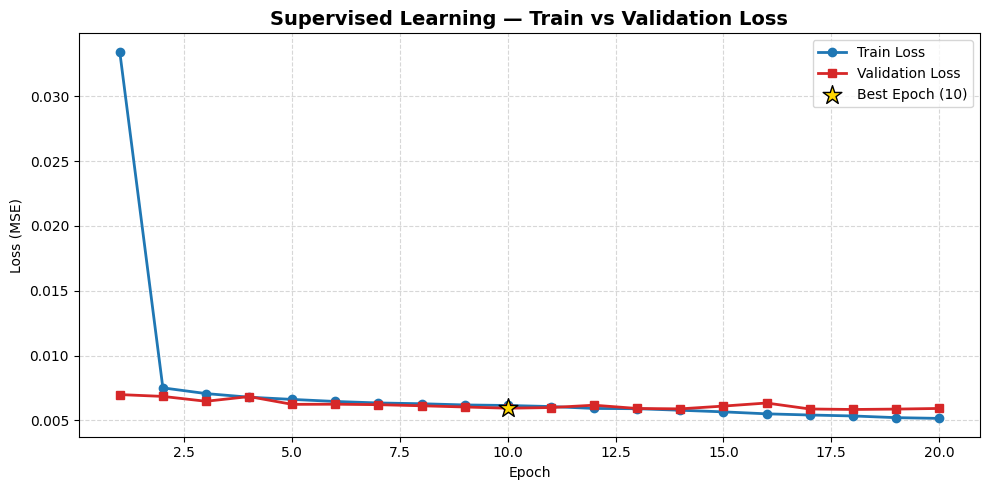

[PLOT] Đã lưu đồ thị 'Supervised Learning — Train vs Validation Loss' tại: /content/drive/MyDrive/tapdulieu/loss_curve_supervised.png


In [ ]:
report_stage("Supervised Learning", sup_train_losses, sup_val_losses,
             best_epoch_sup, best_val_loss_sup)
plot_losses(sup_train_losses, sup_val_losses,
            title="Supervised Learning — Train vs Validation Loss",
            save_path=f"{DATA_DIR}/loss_curve_supervised.png",
            best_epoch=best_epoch_sup)

In [ ]:
print("\n[FINAL SUMMARY]")
print(f"   Supervised → Best Epoch: {best_epoch_sup} | Best Val Loss: {best_val_loss_sup:.4f}")


[FINAL SUMMARY]
   Supervised → Best Epoch: 10 | Best Val Loss: 0.0059


In [ ]:
# @title

scramble_depth = 15
test_cube = scramble_cube(scramble_depth)
print(f"Khối Rubik bị xáo ngẫu nhiên {scramble_depth} bước.")
print(f"Chuỗi trạng thái: {test_cube.to_cubestring()}\n")

solver = UltimateBatchSolver(model, device, weight=1.4, batch_size=128)
start_time = time.time()
solution = solver.solve(test_cube, max_nodes=3000000)
end_time = time.time()
if solution:
    print(f" AI ĐÃ GIẢI THÀNH CÔNG KHỐI RUBIK!")
    print(f" Các bước giải ({len(solution)} bước): {' '.join(solution)}")
    print(f"⏱ Thời gian tìm kiếm: {end_time - start_time:.4f} giây")
    print(f" Tổng số trạng thái thực tế đã lật: {solver.nodes_expanded:,}")
    verification_cube = test_cube.copy()
    verification_cube.apply_moves(solution)
    print(f" Xác thực trạng thái khối: {'HỢP LỆ (ĐÃ GIẢI XONG)' if verification_cube.is_solved() else 'THẤT BẠI'}")
else:
    print(" AI không tìm thấy lời giải trong giới hạn.")

Khối Rubik bị xáo ngẫu nhiên 15 bước.
Chuỗi trạng thái: FFBDUDFLLBRUFRLRBDRDULFDUUDRRBBDLDRFLBDBLULRFRUUFBULFB

   [Solver] AI dự đoán cube cách đích: 21.01 bước. Batch Size = 128
 AI ĐÃ GIẢI THÀNH CÔNG KHỐI RUBIK!
 Các bước giải (21 bước): B R' B D' R F D R' D' R' F' D F L D' B B D L D' U
⏱ Thời gian tìm kiếm: 11.0433 giây
 Tổng số trạng thái thực tế đã lật: 34,332
 Xác thực trạng thái khối: HỢP LỆ (ĐÃ GIẢI XONG)
